In [2]:
import utils_FaIR_JAX
import matplotlib.pyplot as plt
import glob
import numpy as np
import jax.numpy as jnp

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

### Phase 1: Calibrate climate sensitivity via prescribed CO2 concentrations -> $\Delta T$

In [1]:
conc_path = '/Users/chriswomack/Documents/PhD/Project 2/data/MESM/conc_driven'
conc_1pct_path = f'{conc_path}/1PRCO2/'
conc_2CO2_path = f'{conc_path}/2CO2/'

In [3]:
def calculate_ensemble_average(file_pattern):
    # Find all files matching the string pattern (e.g., 'dt2m_ascii_*.txt')
    file_list = glob.glob(file_pattern)

    if not file_list:
        print("No files found matching the pattern.")
        return None

    all_data = []

    for file in file_list:
        # Load the data; np.loadtxt handles the whitespace formatting automatically
        # usecols=(1,) extracts the values from the 2nd column in the text file
        # (which corresponds to your data values like -0.036, 0.064, etc.)
        data = np.loadtxt(file, usecols=(1,))
        all_data.append(data)

    # Stack the list into a 2D array: (number_of_members, number_of_timesteps)
    ensemble_stack = np.stack(all_data)

    # Take the mean across the ensemble members (axis 0)
    ensemble_average = np.mean(ensemble_stack, axis=0)

    return ensemble_average

In [19]:
avg_1pct = calculate_ensemble_average(conc_1pct_path + 'dt2m_ascii_*.txt')
avg_2CO2 = calculate_ensemble_average(conc_2CO2_path + 'dt2m_ascii_*.txt')

target_dict = {'1pctCO2': avg_1pct, 'abrupt-2xCO2': avg_2CO2}

In [95]:
n_years_1pct = len(avg_1pct)
n_years_2CO2 = len(avg_2CO2)

base_co2 = 278.3
co2_1pct = base_co2 * (1.01 **  np.arange(n_years_1pct))
conc_mat_1pct = jnp.zeros((3, len(co2_1pct)))
conc_mat_1pct = conc_mat_1pct.at[0,:].set(co2_1pct)
conc_mat_1pct = conc_mat_1pct.at[1,:].set(720.0)
conc_mat_1pct = conc_mat_1pct.at[2,:].set(270.0)

co2_abrupt_2x = np.full(n_years_2CO2, 2 * base_co2)
conc_mat_2x = jnp.zeros((3, len(co2_abrupt_2x)))
conc_mat_2x = conc_mat_2x.at[0,:].set(co2_abrupt_2x)
conc_mat_2x = conc_mat_2x.at[1,:].set(720.0)
conc_mat_2x = conc_mat_2x.at[2,:].set(270.0)

conc_dict = {'1pctCO2': conc_mat_1pct, 'abrupt-2xCO2': conc_mat_2x}
emis_dict = {'1pctCO2': jnp.zeros((5, len(co2_1pct))), 'abrupt-2xCO2': jnp.zeros((5, len(co2_abrupt_2x)))}

Starting Climate Sensitivity Calibration (Conc -> Temp)...
Step 0 | Loss (Temp MSE): 1.0761
Step 20 | Loss (Temp MSE): 0.3796
Step 40 | Loss (Temp MSE): 0.3622
Step 60 | Loss (Temp MSE): 0.3287
Step 80 | Loss (Temp MSE): 0.3052
Step 100 | Loss (Temp MSE): 0.2895
Step 120 | Loss (Temp MSE): 0.2813
Step 140 | Loss (Temp MSE): 0.2780
Step 160 | Loss (Temp MSE): 0.2770
Step 180 | Loss (Temp MSE): 0.2768
Step 200 | Loss (Temp MSE): 0.2767
Step 220 | Loss (Temp MSE): 0.2766
Step 240 | Loss (Temp MSE): 0.2766
Step 260 | Loss (Temp MSE): 0.2765
Step 280 | Loss (Temp MSE): 0.2764
Step 300 | Loss (Temp MSE): 0.2764
Step 320 | Loss (Temp MSE): 0.2763
Step 340 | Loss (Temp MSE): 0.2762
Step 360 | Loss (Temp MSE): 0.2762
Step 380 | Loss (Temp MSE): 0.2761
Step 400 | Loss (Temp MSE): 0.2760
Step 420 | Loss (Temp MSE): 0.2760
Step 440 | Loss (Temp MSE): 0.2759
Step 460 | Loss (Temp MSE): 0.2758
Step 480 | Loss (Temp MSE): 0.2757
Step 499 | Loss (Temp MSE): 0.2757


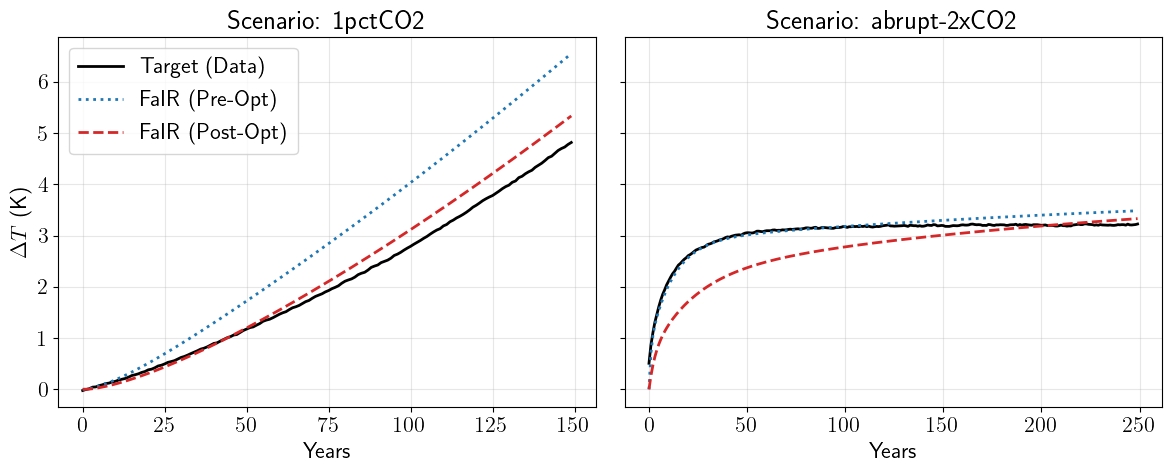

In [68]:
filepath = 'data/JAX_calibration/calib_MESM_CO2_only_old.pkl'
theta0 = utils_FaIR_JAX.make_theta0(mode='FaIR')
learning_rate = 5e-2
n_steps = 500
dt = 0.1
theta_opt, theta_opt_dict = utils_FaIR_JAX.calibrate_climate_sensitivity(filepath, emis_dict, conc_dict, target_dict, theta0, dt, n_steps, learning_rate=1e-2)
utils_FaIR_JAX.plot_calibration_results(conc_dict, emis_dict, target_dict, theta0, theta_opt, dt=0.1)

### Phase 2: Calibrate carbon cycle via emissions -> concentrations

In [98]:
emis_path = '/Users/chriswomack/Documents/PhD/Project 2/data/MESM/emis_driven'
emis_1pct_path = f'{emis_path}/1PRCO2/carbemiss.txt'

emis_1pct = np.loadtxt(emis_1pct_path, usecols=(2,), skiprows=2)
emis_mat_1pct = jnp.zeros((5, len(emis_1pct)))
emis_mat_1pct = emis_mat_1pct.at[0,:].set(emis_1pct)
emis_dict = {'1pctCO2': emis_mat_1pct}
target_conc_dict = {'1pctCO2': conc_mat_1pct}

Starting Carbon Cycle Calibration (Emis -> Conc)...
Step 0 | Loss (Conc MSE): 2168.8643


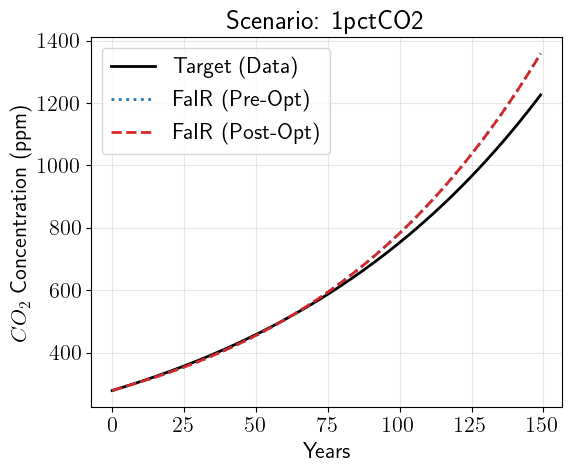

In [143]:
filepath = 'data/JAX_calibration/calib_MESM_emis_to_conc.pkl'
learning_rate = 1e-1
n_steps = 1
dt = 0.1
theta_opt_emis, theta_opt_dict_emis = utils_FaIR_JAX.calibrate_carbon_cycle(filepath, emis_dict, target_conc_dict, theta0, dt, n_steps, learning_rate=1e-2)
utils_FaIR_JAX.plot_calibration_results(None, emis_dict, target_conc_dict, theta0, theta_opt_emis, dt=0.1, calib='Carbon')

### Phase 3: emissions to temperature (verification)

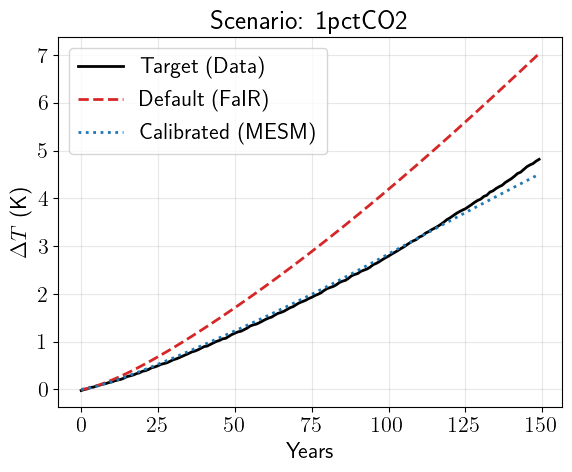

In [157]:
utils_FaIR_JAX.plot_model_comparison(emis_dict, {'1pctCO2': target_dict['1pctCO2']}, theta0, mode='MESM', dt=0.1)